# Lotka-Volterra Posterior Comparison

In [ ]:
import importlib
importlib.reload(m)

<module 'lv_methods' from '/home/hazelframpton/ABC/final/lv_methods.py'>

In [195]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import pickle
import pathlib

import lotka_volterra as lv
import lv_methods as m

# publication-quality rcParams
mpl.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#333333',
    'axes.linewidth':    0.9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'axes.axisbelow':    True,
    'grid.color':        '#eeeeee',
    'grid.linewidth':    0.7,
    'xtick.color':       '#333333',
    'ytick.color':       '#333333',
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'font.family':       'sans-serif',
    'font.size':         14,
    'axes.titlesize':    16,
    'axes.titleweight':  'normal',
    'axes.labelsize':    16,
    'legend.frameon':    False,
    'legend.fontsize':   22,
    'pdf.fonttype':      42,        # embed as TrueType, not Type3 (poster-safe)
    'ps.fonttype':       42,
    'svg.fonttype':      'none',    # keep text as text in SVG
})

In [ ]:

SEED   = 1
BUDGET = 20_000          # total simulator calls per method 

# posterior sample counts 
N_POST_NPE = 4_000
N_POST_NLE = 2_000


ABC_KEEP_FRAC     = 0.05          
WASS_KEEP_FRAC    = 0.03        
ABC_MCMC_PROP_SD  = 0.6          # RW proposal std on log-theta
BSL_N_BATCH       = 25            
BSL_PROPOSAL_SD   = 0.15


CACHE_DIR = pathlib.Path("lv_posterior_cache")
CACHE_DIR.mkdir(exist_ok=True)

lv.set_seed(SEED)
rng = np.random.default_rng(SEED)

x_o : [34.435 11.358  8.275  7.012  0.989  0.975  0.939  0.897  0.523]
log true theta: [-4.605 -0.693  0.    -4.605]


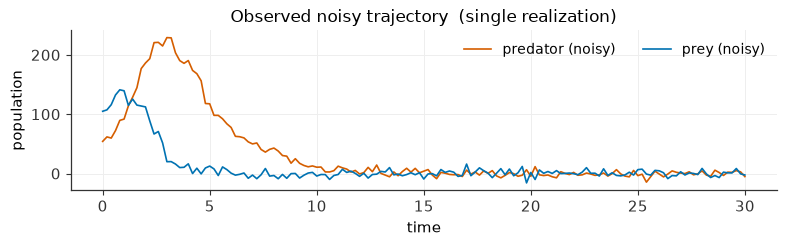

In [ ]:

# Generate the observation 
y_obs, x_o = lv.make_observation(true_params=lv.TRUE_PARAMS,
                                 noise_sd=lv.OBS_NOISE_SD, seed=SEED)
print("x_o :", np.round(x_o, 3))
print("log true theta:", np.round(lv.LOG_TRUE_PARAMS, 3))


fig, ax = plt.subplots(figsize=(8, 2.6))
t_grid = np.arange(len(y_obs)) * lv.DT
ax.plot(t_grid, y_obs[:, 0], color='#D55E00', lw=1.2, label='predator (noisy)')
ax.plot(t_grid, y_obs[:, 1], color='#0072B2', lw=1.2, label='prey (noisy)')
ax.set_xlabel('time'); ax.set_ylabel('population')
ax.set_title('Observed noisy trajectory  (single realization)')
ax.legend(loc='upper right', ncol=2)
plt.tight_layout(); plt.show()

In [ ]:

def cached(name, fn, *args, force=False, **kwargs):
    path = CACHE_DIR / f"{name}.pkl"
    if path.exists() and not force:
        with open(path, "rb") as f:
            samples = pickle.load(f)
        print(f"[cache]  {name:>18s}  loaded  ({samples.shape[0]} samples)")
        return samples
    samples = fn(*args, **kwargs)
    with open(path, "wb") as f:
        pickle.dump(samples, f)
    print(f"[run  ]  {name:>18s}  saved   ({samples.shape[0]} samples)")
    return samples

## Run each method

Each of the next six cells runs one method and caches the resulting posterior
samples. Rerunning a cell without deleting its cache is a no-op; pass
`force=True` to re-run.

In [151]:
abc_rej = cached("abc_rejection", m.run_abc_rejection,
                 x_o, BUDGET, keep_fraction=ABC_KEEP_FRAC, rng=rng)

ABC-Rejection:   0%|          | 0/20000 [00:00<?, ?it/s]

[ABC-Rej]  kept 873/17446 (acc=5.0%), eps_effective=4.491, dist_quantiles(10/50/90)={10: np.float64(5.787), 50: np.float64(7.436), 90: np.float64(8.476)}
[run  ]       abc_rejection  saved   (873 samples)


In [ ]:
abc_mcmc = cached("abc_mcmc", m.run_abc_mcmc,
                  x_o, BUDGET,
                  epsilon=None,                            
                  proposal_sd=ABC_MCMC_PROP_SD, rng=rng)

ABC-MCMC:   0%|          | 0/19000 [00:00<?, ?it/s]

[ABC-MCMC] acc=52.8%, eps=2.718, pilot d(1/10/50/90)={1: np.float64(2.718), 10: np.float64(5.762), 50: np.float64(7.386), 90: np.float64(8.431)}, chain d(10/50/90)={10: np.float64(2.35), 50: np.float64(5.033), 90: np.float64(7.503)}
[run  ]            abc_mcmc  saved   (17100 samples)


In [153]:
wass_abc = cached("wasserstein_abc", m.run_wasserstein_abc,
                  y_obs, BUDGET, keep_fraction=WASS_KEEP_FRAC, rng=rng)

Wasserstein-ABC:   0%|          | 0/20000 [00:00<?, ?it/s]

[W-ABC]    kept 526/17526 (acc=3.0%), eps_effective=1.045, dist_quantiles(10/50/90)={10: np.float64(1.377), 50: np.float64(1.893), 90: np.float64(65.882)}
[run  ]     wasserstein_abc  saved   (526 samples)


In [119]:
bsl = cached("bsl", m.run_bsl,
             x_o, BUDGET,
             n_batch=BSL_N_BATCH, proposal_sd=BSL_PROPOSAL_SD, rng=rng)

BSL:   0%|          | 0/800 [00:00<?, ?it/s]

[BSL]      acc=18.9%, M=800 steps × n_batch=25, kept=640
[run  ]                 bsl  saved   (640 samples)


In [120]:
npe = cached("npe", m.run_npe,
             x_o, BUDGET, n_posterior_samples=N_POST_NPE)

Simulating LV:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/hazelframpton/ABC/.venv/lib64/python3.14/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 3, 7] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 123 epochs.

  0%|          | 0/4000 [00:00<?, ?it/s]

[run  ]                 npe  saved   (4000 samples)


In [121]:
nle = cached("nle", m.run_nle,
             x_o, BUDGET, n_posterior_samples=N_POST_NLE)

Simulating LV:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/hazelframpton/ABC/final/lv_methods.py:399: UserWarning: NLE gives systematically wrong results when exclude_invalid_x=True.
/home/hazelframpton/ABC/.venv/lib64/python3.14/site-packages/sbi/inference/trainers/base.py:296: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 3, 7] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 228 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/7000 [00:00<?, ?it/s]

[run  ]                 nle  saved   (2000 samples)


In [ ]:

posteriors = {
    "ABC-Rejection":    dict(samples=abc_rej,  color="#6CB7FF",
                             ls="-", amortised=False),
    "ABC-MCMC":         dict(samples=abc_mcmc, color="#74DFCD",
                             ls="-", amortised=False),
    "Wasserstein-ABC":  dict(samples=wass_abc, color="#FEDE7B",
                             ls="-", amortised=False),
    "BSL":              dict(samples=bsl,      color="#F1977F",
                             ls="-", amortised=False),
    "NPE":              dict(samples=npe,      color="#693594",
                             ls="--",  amortised=True),
    "NLE":              dict(samples=nle,      color="#B68Df5",
                             ls="--",  amortised=True),
}


LEGEND_ORDER = ["NPE", "NLE",
                "ABC-Rejection", "ABC-MCMC", "Wasserstein-ABC", "BSL"]

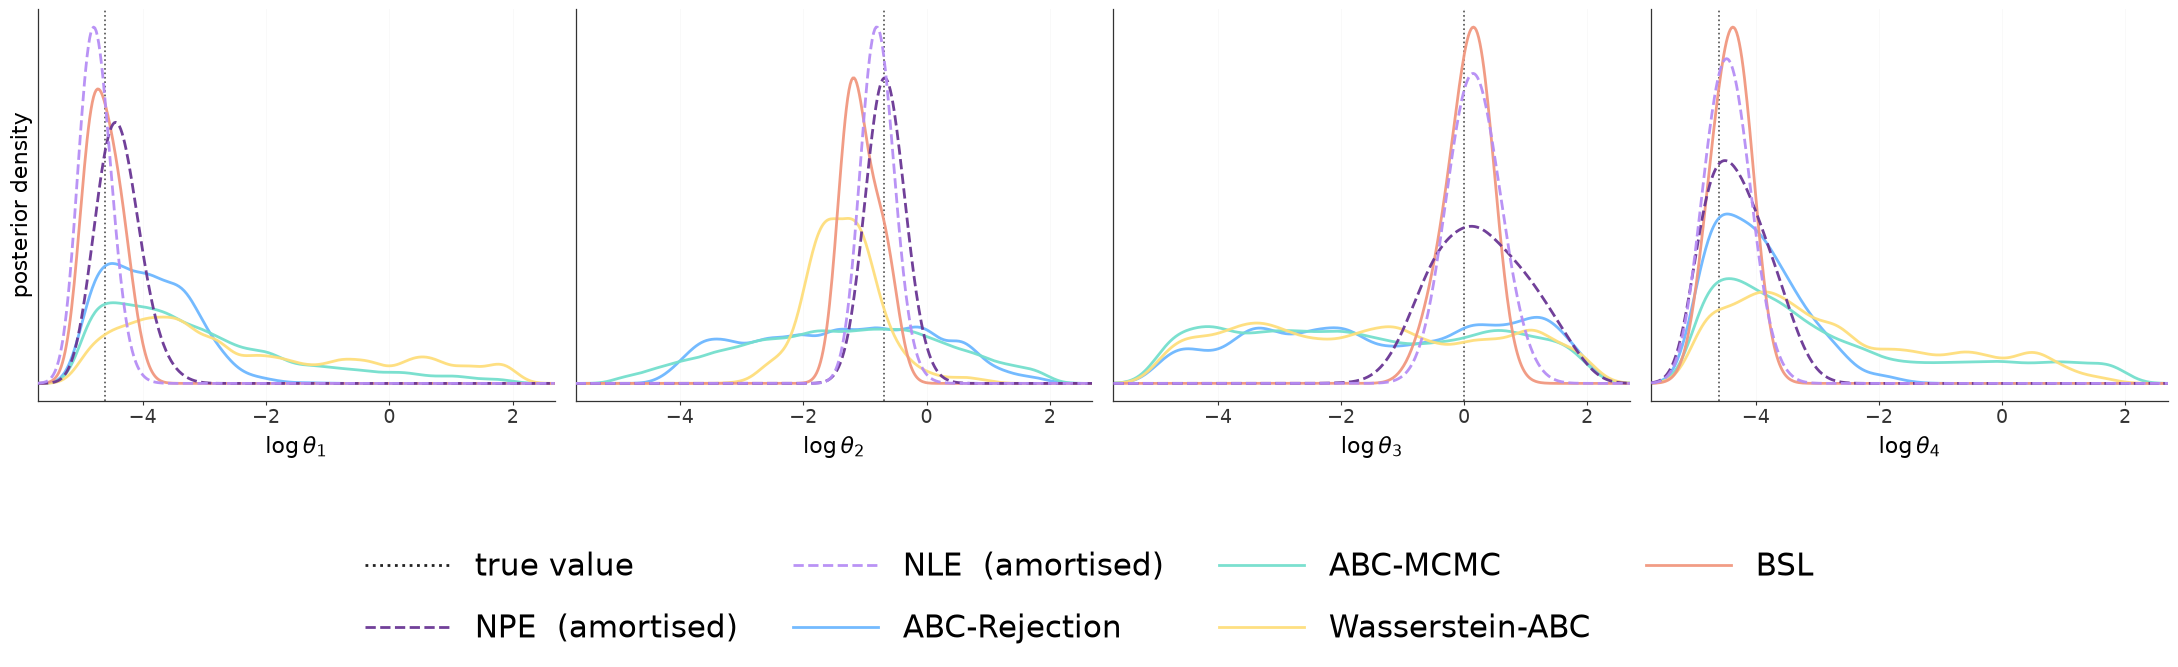

In [ ]:

def kde_line(samples, grid, abs_bw=None):
    s = np.asarray(samples)
    if s.std() < 1e-8:
        d = np.zeros_like(grid); d[np.argmin(np.abs(grid - s.mean()))] = 1.0
        return d
    if abs_bw is None:
        return stats.gaussian_kde(s, bw_method='scott')(grid)
    return stats.gaussian_kde(s, bw_method=abs_bw / s.std())(grid)


def panel_grid(param_idx, pad_frac=0.10, n_grid=400):
    """Adaptive x-range: [min - pad, max + pad] across all methods' samples."""
    lo = min(p["samples"][:, param_idx].min() for p in posteriors.values())
    hi = max(p["samples"][:, param_idx].max() for p in posteriors.values())
    pad = pad_frac * (hi - lo)
    return np.linspace(lo - pad, hi + pad, n_grid)


fig, axes = plt.subplots(1, lv.N_PARAMS,figsize=(22, 6),
                         sharey=False, constrained_layout=False)

for j, ax in enumerate(axes):
    grid = panel_grid(j)
    pooled = np.concatenate([p["samples"][:, j] for p in posteriors.values()])
    abs_bw = 1.06 * pooled.std() * len(pooled) ** (-1/5)   # Silverman on pool
    ax.axvline(lv.LOG_TRUE_PARAMS[j], color='#222222', ls=':', lw=1.2, alpha=0.8)
    for name in LEGEND_ORDER:
        p = posteriors[name]
        d = kde_line(p["samples"][:, j], grid, abs_bw=abs_bw)   # <-- pass abs_bw
        ax.plot(grid, d, color=p["color"], ls=p["ls"], lw=2.0, alpha=0.95,
                zorder=3 if p["amortised"] else 2, label=name)
    ax.set_xlabel(lv.PARAM_NAMES[j], labelpad=6)
    ax.set_yticks([])
    ax.tick_params(axis='x', length=3, pad=2)
    ax.grid(axis='x', alpha=0.35)
    ax.margins(x=0)

axes[0].set_ylabel("posterior density")

#legend
handles, labels = axes[0].get_legend_handles_labels()

label_map = {name: (name + "  (amortised)" if posteriors[name]["amortised"]
                    else name) for name in LEGEND_ORDER}
handles_ord = [handles[labels.index(n)] for n in LEGEND_ORDER]
labels_ord  = [label_map[n] for n in LEGEND_ORDER]


truth_handle = plt.Line2D([0], [0], color='#222222', ls=':', lw=1.2)
handles_ord = [truth_handle] + handles_ord
labels_ord  = ["true value"] + labels_ord


handles, labels = axes[0].get_legend_handles_labels()
label_map = {name: (name + "  (amortised)" if posteriors[name]["amortised"]
                    else name) for name in LEGEND_ORDER}
handles_ord = [handles[labels.index(n)] for n in LEGEND_ORDER]
labels_ord  = [label_map[n] for n in LEGEND_ORDER]
truth_handle = plt.Line2D([0], [0], color='#222222', ls=':', lw=2.0)
handles_ord = [truth_handle] + handles_ord
labels_ord  = ["true value"] + labels_ord

fig.legend(handles_ord, labels_ord,
           loc='lower center', ncol=4,                 # 4 cols -> 2 rows of 7 items
           bbox_to_anchor=(0.5, -0.14),                # pushed well clear of x-labels
           handlelength=2.8, columnspacing=1.8,
           labelspacing=1.0, frameon=False)


#fig.suptitle("Lotka-Volterra:  marginal posteriors from six inference methods",
 #            y=1.01, fontsize=13)
fig.tight_layout(rect=[0, 0.18, 1, 1]) 
fig.savefig('lv_posteriors_final.svg', bbox_inches='tight')

plt.show()

In [ ]:

# Save vector formats for the poster

out_dir = pathlib.Path("figures"); out_dir.mkdir(exist_ok=True)

fig.savefig(out_dir / "lv_posterior_comparison.pdf",
            bbox_inches='tight', pad_inches=0.05)
fig.savefig(out_dir / "lv_posterior_comparison.svg",
            bbox_inches='tight', pad_inches=0.05)
fig.savefig(out_dir / "lv_posterior_comparison.png",
            bbox_inches='tight', pad_inches=0.05, dpi=400)
print("saved to", out_dir.resolve())

saved to /home/hazelframpton/ABC/final/figures
